In [1]:
%matplotlib widget
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double
# dim: int or "Any"
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:

# from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
# from compressibleSPH.schemeBuilder import buildScheme
# from compressibleSPH.caseUtils.sedov.initial import buildSedov
# goalRadius = 0.8

# gamma = 5/3
# rho0 = 1
# E0 = 1

# nx = 200
# # gamma = 5/3
# # leftState = sodInitialState(1, 1, 0)
# # rightState = sodInitialState(0.1795, 0.25, 0)
# samplingRatio = 1
# smoothIC = True
# timeLimit = 0.15

# L = 2
# dim = 2
# n_h = 4
# device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
# dtype = torch.float32

# config = SimulationConfig(
#     domain = buildDomainDescription(L, dim, True, device, dtype),
#     dim = dim,
#     kernel = KernelFunctions.B7,
#     targetNeighbors = n_h_to_nH(n_h, dim),
#     supportMode = SupportScheme.Gather,
#     gradientMode = GradientScheme.Difference,
#     laplacianMode = LaplacianScheme.Brookshaw,
#     integrationScheme = IntegrationSchemeType.rungeKutta4,
#     samplingScheme = SamplingScheme.regular,
#     device = device,
#     dtype = dtype,
#     dt = 1e-3,
#     adaptiveDt = False,
#     cflFactor=0.3,
#     verletScale=1.0
# )



# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('compSPH')

# compressibleSPHConfig = SimulationConfig(
#     gamma = gamma,
#     rho0 = rho0,
#     # diffusionParams = diffusionParams,
# )
# integrator = getIntegrator(config.integrationScheme)

# from compressibleSPH.enumTypes import ViscositySwitch
# compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.CullenHopkins

In [3]:
nx = 200
gamma = 5/3
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

L = 1
dim = 2
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

config = SimulationConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = False,
    cflFactor=0.3,
    # verletScale=1.0
)

# diffusionParams = DiffusionParameters()
# diffusionParams.c_s = 1
# diffusionParams.C_l = 1
# diffusionParams.C_q = 2
# diffusionParams.Cu_l = 1
# diffusionParams.Cu_q = 2
# diffusionParams.K = 1.0
# diffusionParams.thermalConductivity = 0.5
# diffusionParams.viscosityTerm = ViscosityTerms.Monaghan1992.value
# diffusionParams.thermalConducitiyTerm = ViscosityTerms.Price2012_98.value
# diffusionParams.scaleBeta = False
# diffusionParams.monaghanSwitch = True
# diffusionParams.correctXi = True


from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
from compressibleSPH.schemeBuilder import buildScheme

SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('crkSPH')
rho0 = 1.0
compressibleSPHConfig = SimulationConfig(
    gamma = gamma,
    rho0 = rho0,
    # diffusionParams = diffusionParams,
)
integrator = getIntegrator(config.integrationScheme)

from compressibleSPH.enumTypes import ViscositySwitch
compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch

In [4]:
# compSystem = buildSedov(
#     SimulationSystem, SimulationState, 
#     config = config,
#     nx = nx, dim = dim, domainExtent = L, 
#     periodicDomain = True, 
#     rho0 = rho0, E0 = E0, 
#     initialization = 'quadrant', 
#     gamma = gamma, kernel = config.kernel, 
#     targetNeighbors = config.targetNeighbors, 
#     dtype = config.dtype, device = config.device)

In [5]:

from warp import Kernel

from compressibleSPH.config import SimulationConfig
from compressibleSPH.utils import *
from sphWarpCore import *
import torch
from compressibleSPH.system import *
from compressibleSPH.modules import idealGasEOS, evaluateOptimalSupport
from compressibleSPH.enumTypes import *
# from optimalSupport import evaluateOptimalSupport

# dim = 2
# domain = buildDomainDescription(L, dim, periodic = periodicDomain, device = device, dtype = dtype)

particles_ = sampleRegularParticles(nx, config.domain, config.targetNeighbors)
# domain = buildDomainDescription(domainExtent * 1.5, dim, periodic = periodicDomain, device = device, dtype = dtype)
particles_ = particles_._replace(masses = particles_.masses * compressibleSPHConfig.rho0)



particles = SimulationState(
    positions = particles_.positions,
    supports = particles_.supports,
    masses = particles_.masses,
    densities = particles_.densities,
    velocities = torch.zeros_like(particles_.positions),
    
    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles_.positions.shape[0],
    
    internalEnergies = None,
    totalEnergies = None,
    entropies = None,
    pressures = None,
    soundspeeds = None,

    divergence=torch.zeros_like(particles_.densities),
    alpha0s= torch.ones_like(particles_.densities),
    alphas= torch.ones_like(particles_.densities),
)


densities = warpOperation(
    particles, 
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = SupportScheme.Gather,
        gradientMode = config.gradientMode,
        laplacianMode = config.laplacianMode,
    ),
    domain = config.domain,
)
particles.densities = densities

compressibleSPHConfigAdapt = CompressibleSPHConfig(
    adaptiveSupportIterations=16,
    adaptiveSupportThreshold=1e-3,
    adaptiveSupportScheme=AdaptiveSupportScheme.NoScheme,
)

# neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
# config = {'targetNeighbors': targetNeighbors, 'domain': domain, 'support': {'iterations': 16, 'scheme': 'Monaghan'}, 'neighborhood': {'algorithm': 'compact'}}
# rho, h, rhos, hs, neighborhood = evaluateOptimalSupport(particles, wrappedKernel, neighborhood, SupportScheme.Gather, config)


rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfigAdapt)


adjacency = buildVerletList(particles, domain = config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric, priorNeighborhood=None, verbose=False)

print(f'Optimal Support min: {h_optimal.min()}, max: {h_optimal.max()}, mean: {h_optimal.mean()}')
print(f'Number of neighbors min: {adjacency.numNeighbors.min()}, max: {adjacency.numNeighbors.max()}, mean: {adjacency.numNeighbors.float().mean()}')

Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 2.18 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid 82cf6d3 load on device 'cuda:0' took 4.46 ms  (cached)
Optimal Support min: 0.019999999552965164, max: 0.019999999552965164, mean: 0.020000003278255463
Number of neighbors min: 45, max: 49, mean: 47.099998474121094


In [6]:

# compressibleSPHConfig = CompressibleSPHConfig(
#     adaptiveSupportIterations=16,
#     adaptiveSupportThreshold=1e-3,
#     adaptiveSupportScheme=AdaptiveSupportScheme.Owen,
# )

# neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
# config = {'targetNeighbors': targetNeighbors, 'domain': domain, 'support': {'iterations': 16, 'scheme': 'Monaghan'}, 'neighborhood': {'algorithm': 'compact'}}
# rho, h, rhos, hs, neighborhood = evaluateOptimalSupport(particles, wrappedKernel, neighborhood, SupportScheme.Gather, config)

rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfigAdapt)



adjacency = buildVerletList(particles, domain = config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric, priorNeighborhood=None, verbose=False)

print(f'Optimal Support min: {h_optimal.min()}, max: {h_optimal.max()}, mean: {h_optimal.mean()}')
print(f'Number of neighbors min: {adjacency.numNeighbors.min()}, max: {adjacency.numNeighbors.max()}, mean: {adjacency.numNeighbors.float().mean()}')

Optimal Support min: 0.019999999552965164, max: 0.019999999552965164, mean: 0.020000003278255463
Number of neighbors min: 45, max: 49, mean: 47.099998474121094


In [8]:
import math
r = torch.linalg.norm(particles.positions, dim=-1)

regionA = r < 0.2
regionB = (r >= 0.2) & (r < 0.4)
regionC = r >= 0.4  

Pinitial = torch.zeros_like(particles.densities)
vinitial_angular = torch.zeros_like(particles.densities)

Pinitial[regionA] = 12.5 * r[regionA]**2 + 5
Pinitial[regionB] = 12.5 * r[regionB]**2 - 20 * r[regionB] + 4 * torch.log(5*r[regionB]) + 9
Pinitial[regionC] = 3 + 4 * math.log(2)

vinitial_angular[regionA] = 5 * r[regionA]
vinitial_angular[regionB] = 2 - 5 * r[regionB]
vinitial_angular[regionC] = 0

vinitial = torch.zeros_like(particles.positions)
vinitial[:,0] = -vinitial_angular * particles.positions[:,1] / r
vinitial[:,1] = vinitial_angular * particles.positions[:,0] / r

In [9]:

# particleState.supports = h_optimal

particles.densities = rho_optimal
particles.supports = h_optimal

# P_initial = torch.ones_like(particles.densities)
u = 1 / (gamma - 1) * (Pinitial / rho_optimal)
# A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = P_initial, rho = rho_optimal, gamma = gamma)
A_, u_, P_, c_s = idealGasEOS(A = None, u = u, P = None, rho = rho_optimal, gamma = gamma)

internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(torch.zeros_like(particles.positions), dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

simulationState_ = SimulationState(
    positions = particles.positions,
    supports = particles.supports,
    masses = particles.masses,
    densities = particles.densities,        
    velocities = vinitial,

    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles.positions.shape[0],
    
    internalEnergies = u_,
    totalEnergies = totalEnergy,
    entropies = A_,
    pressures = P_,
    soundspeeds = c_s,

    alphas = torch.ones_like(particles.densities),
    alpha0s = torch.ones_like(particles.densities),
    divergence=torch.zeros_like(particles.densities),
)
    

In [10]:
from compressibleSPH.modules.timestep.compressible import computeTimestep

In [11]:
adjacency = buildVerletList(simulationState_, 
                            domain = config.domain,
                            verletScale = 2**(1/config.dim), supportMode = config.supportMode)

compressibleSystem = SimulationSystem(
    state=simulationState_, 
    adjacency = adjacency, 
    domain = config.domain)

# particleSystem = SimulationSystem(
#     systemState = simulationState_,
#     domain = domain,
#     neighborhoodInfo = neighborhood,
#     t = 0
# )

config.dx = L / nx
config.dt = computeTimestep(compressibleSystem, config, compressibleSPHConfig, dt = config.dt)

In [12]:
from compressibleSPH.schemes.compSPH import compSPH_step

In [16]:
# runningState = compSPHSystem.initializeNewState()

# result = integrator.function(
#     state = runningState,
#     f = compSPH_step,
#     dt = config.dt,  
#     config = config,
#     compParams = compSPHConfig,
#     verbose = False,|
# )
compressibleSPHConfig.energyScheme = EnergyScheme.CRK
compressibleSPHConfig.adaptiveSupportScheme = AdaptiveSupportScheme.NoScheme
runningState = compressibleSystem.initializeNewState()

In [17]:
display(compressibleSPHConfig)

CRKSPHConfig(gamma=1.6666666666666667, backgroundPressure=0.0, rho0=1.0, adaptiveSupportScheme=<AdaptiveSupportScheme.NoScheme: 0>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=True, diffusionParams=DiffusionParameters(
	c_s=1,
	C_l=1,
	C_q=1,
	Cu_l=1,
	Cu_q=1,
	K=1.0,
	thermalConductivity=0.5,
	viscosityTerm=3,
	thermalConducitiyTerm=7,
	scaleBeta=False,
	monaghanSwitch=True,
	correctXi=True,
), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.NoneSwitch: 6>, limitXi=True, correctVelocityGradient=False, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='CRKSPH', boundaryConditions=[], energyScheme=<EnergyScheme.CRK: 5>, crkViscosityParams=CRKViscosity(
	eta_fold=0.2,
	eta_crit=0.3333333,
	enableCRKLimiter=True,
	enableVanLeerLimiter=True,
	forceVanLeerOff=False,
	forceVanLeerOn=False,
), compatibleEnergy=True)

In [20]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap
markerSize = 4
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.pressures,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.cividis,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "pressures",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

RFBOutputContext()

In [21]:
runningState.state.densities

tensor([1.0004, 1.0004, 1.0004,  ..., 1.0004, 1.0004, 1.0004], device='cuda:0')

In [24]:
# config.dt = 2.5e-3
t_limit = 3.0
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 256

runningState = compressibleSystem.initializeNewState()

trajectory = []

priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
        # priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    trajectory.append(
        (i, (i+1)*config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )


    if i % 10 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.pressures,
            },
            newParticleState = runningState.state,
        )
        # axis[0,0].clear()
        # axis[0,1].clear()
        # axis[1,0].clear()
        # axis[1,1].clear()
        # plotShock(fig, axis, runningState)
        # fig.canvas.draw()
        # fig.canvas.flush_events()
        # fig.savefig(f'output/sedov/frame_{i:05d}.png', dpi = 300)

    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break

Running with dt: 0.001, which gives nSteps: 3000


  0%|          | 0/3000 [00:00<?, ?it/s]

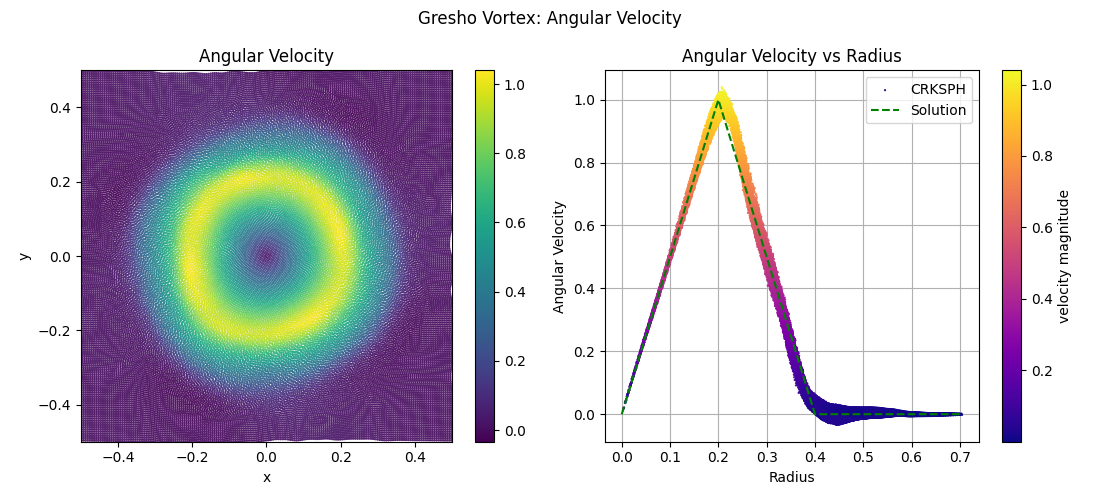

In [47]:
r = torch.linalg.norm(runningState.state.positions, dim=-1)

fig, axis = plt.subplots(1,2, figsize = (11,5), squeeze=False)
s = 0.33

vel = runningState.state.velocities
angularVel = vel[:,0] * (-runningState.state.positions[:,1] / r) + vel[:,1] * (runningState.state.positions[:,0] / r)

sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu(), runningState.state.positions[:,1].cpu(), c = angularVel.cpu(), s = s, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])

axis[0,0].set_xlim(-0.5,0.5)
axis[0,0].set_ylim(-0.5,0.5)
axis[0,0].set_aspect('equal')
axis[0,0].set_xlabel("x")
axis[0,0].set_ylabel("y")

sc = axis[0,1].scatter(r.cpu(), angularVel.cpu(), c = torch.linalg.norm(vel, dim = -1).cpu(), s = s, cmap = 'plasma', label = 'CRKSPH')
fig.colorbar(sc, ax = axis[0,1], label = 'velocity magnitude')


axis[0,1].plot([0,0.2,0.4, r.max().cpu()], [0, 1, 0,0], 'g--', label = 'Solution')
axis[0,1].legend()
axis[0,1].grid()
axis[0,1].set_axisbelow(True)
axis[0,1].set_xlabel("Radius")
axis[0,1].set_ylabel("Angular Velocity")

axis[0,0].set_title("Angular Velocity")
axis[0,1].set_title("Angular Velocity vs Radius")

fig.suptitle("Gresho Vortex: Angular Velocity")

fig.tight_layout()

In [ ]:
# dt = config.dt * 0.5

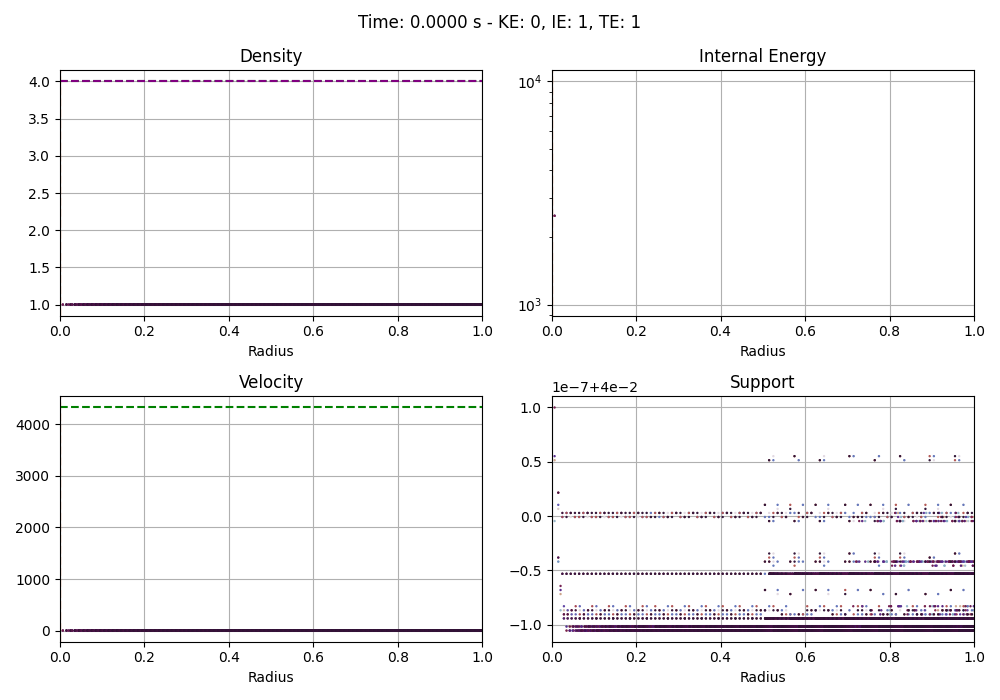

In [ ]:
# config.dt = 1e-4
t_limit = goalTime
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 256

runningState = compSPHSystem.initializeNewState()

trajectory = []

priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = compSPH_step,
        dt = config.dt,  
        config = config,
        compParams = compSPHConfig,
        verbose = False,
        # priorStep = None
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    trajectory.append(
        (i, (i+1)*config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )


    if i % 50 == 0 and i > 0:
        # plotter.updateQuantities(
        #     {
        #         "A": runningState.state.internalEnergies,
        #         "B": runningState.state.densities,
        #     },
        # )
        axis[0,0].clear()
        axis[0,1].clear()
        axis[1,0].clear()
        axis[1,1].clear()
        plotShock(fig, axis, runningState)
        fig.canvas.draw()
        fig.canvas.flush_events()
        # fig.savefig(f'output/sedov/frame_{i:05d}.png', dpi = 300)

    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g}")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break

Running with dt: 5.789442002424039e-05, which gives nSteps: 8304


  0%|          | 0/8304 [00:00<?, ?it/s]

KeyboardInterrupt: 

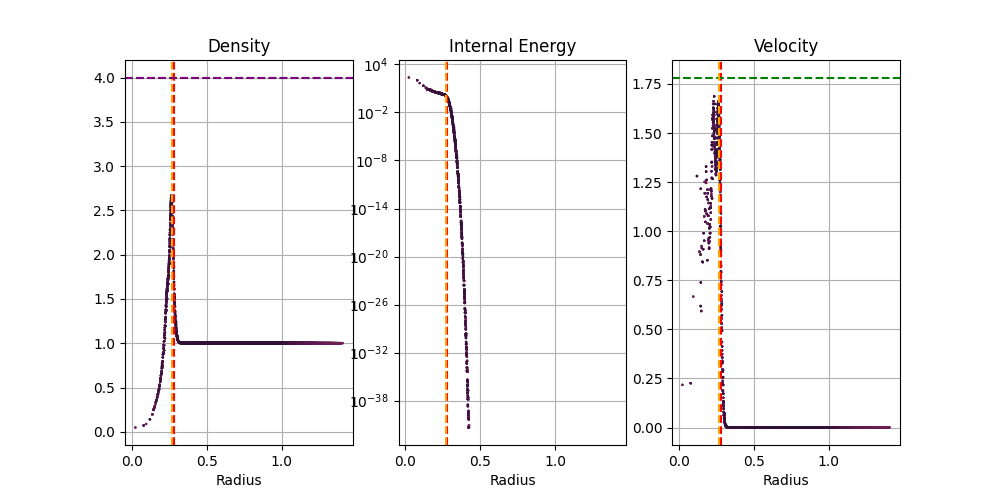

In [ ]:
# torch.linalg.norm(runningState.state.velocities.cpu(), dim = -1).max()
runningState.state.densities.max()

tensor(3.3890, device='cuda:0')

In [ ]:
from compressibleSPH.modules.shockCapturing.common import *
from compressibleSPH.modules.adaptiveSupport import computeOmega, evaluateOptimalSupport
from compressibleSPH.systems.compSPH import CompSPHSystem, CompSPHState
from compressibleSPH.configurations.compSPHConfig import CompSPHConfig
from compressibleSPH.enumTypes import EnergyScheme
from compressibleSPH.system import *
from compressibleSPH.modules import idealGasEOS, evaluateOptimalSupport

schemeConfig = compSPHConfig
currentSystem = runningState.initializeNewState()
currentState = currentSystem.state

rho_optimal, h_optimal, currentSystem.adjacency, *_ = evaluateOptimalSupport(currentState, config, schemeConfig, SupportScheme.Gather, currentSystem.adjacency)
currentState.supports = h_optimal
currentState.densities = rho_optimal

verletScale = 2 ** (1/config.dim)
verletScale = 1

adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = verletScale, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = currentSystem.adjacency,
    verbose = False)

numNeighbors = adjacency.numNeighbors

currentState.densities = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = config.supportMode,
    ),
    domain = config.domain,
    adjacency = adjacency,
)

currentState.entropies, _, currentState.pressures, currentState.soundspeeds = idealGasEOS(
    A = None,
    u = currentState.internalEnergies,
    P = None,
    rho = currentState.densities,
    gamma = schemeConfig.gamma,
)

omega = computeOmega(currentState, 
        OperationProperties(
            kernel = config.kernel,
            supportMode = SupportScheme.Gather,
        ),
        domain = config.domain,
        adjacency = adjacency
)

gradHState = GradHState(
    queryOmegas = omega
)

from compressibleSPH.modules.adaptiveSupport import computeOmega
from compressibleSPH.modules.compSPH.accel import computeCompSPHAccelWarp
from compressibleSPH.modules.compSPH.dudt import computeCompSPHdudtWarp
from compressibleSPH.modules.compSPH.balance import computeCompSPHBalanceTermWarp
from compressibleSPH.enumTypes import EnergyScheme
from compressibleSPH.modules import *
dvdt, currentState.ap_ij, currentState.av_ij = computeCompSPHAccelWarp(
    queryParticles = currentState,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode =  SupportScheme.KernelMeanSymmetric
    ),
    domain = config.domain,
    conductivityParams= schemeConfig.diffusionParams,

    queryEnergies = currentState.internalEnergies,
    queryVelocities= currentState.velocities,
    queryCs = currentState.soundspeeds,
    queryAlphas = currentState.alphas,
    queryPressures = currentState.pressures,

    adjacency = adjacency,
    gradHState = gradHState
)

In [ ]:
from diffSPH.schemes.states.compressiblesph import CompressibleState as CompState
from diffSPH.kernels import getSPHKernelv2
from diffSPH.neighborhood import evaluateNeighborhood

from diffSPH.modules.compSPH import compSPH_acceleration, compSPH_dudt, compute_fij

diffSPHDiffusionConfig = {    
    'diffusion':{
        'C_l': 1,
        'C_q': 0,
        'Cu_l': 1,
        'Cu_q': 0,
        'monaghanSwitch': True,
        'viscosityTerm': 'Monaghan',
        'correctXi': True,
        
        'viscosityFormulation': 'Price2012_98',
        'thermalConductivityFormulation': 'Price2008',
        'signalTerm': 'Price2019',
        'K': 1.0,
        
        'thermalConductivity' : 0.5,
    },
    'diffusionSwitch':{
        'scheme': ViscositySwitch.NoneSwitch,
        'limitXi': False,
    },
    'domain': config.domain,
    'kernel': KernelType.Wendland2,
    'verbose': True,
}

diffSPHState = CompState(
    positions = currentState.positions,
    velocities = currentState.velocities,
    densities = currentState.densities,
    supports = currentState.supports,
    internalEnergies = currentState.internalEnergies,
    totalEnergies = currentState.totalEnergies,
    entropies = currentState.entropies,
    soundspeeds= currentState.soundspeeds,
    masses = currentState.masses,
    kinds = currentState.kinds,
    materials = currentState.materials,
    UIDs = currentState.UIDs,
    pressures = currentState.pressures,
    omega = gradHState.queryOmegas,
)

wrappedKernel = getSPHKernelv2(KernelType.Wendland2)
verletScale = 1
neighborhood, neighbors = evaluateNeighborhood(diffSPHState, config.domain, KernelType.Wendland2, verletScale = verletScale, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)


In [ ]:
from diffSPH.modules.switches.common import computeM as computeM_diffSPH
from diffSPH.modules.switches.common import computeDivergence as computeDivergence_diffSPH
from diffSPH.modules.switches.common import computeShearTensor as computeShearTensor_diffSPH
from diffSPH.enums import SupportScheme as SupportSchemeDiffSPH
from sphWarpCore import SupportScheme

In [ ]:
M = computeM(
    particleState = currentState,
    simulationConfig = config,
    schemeConfig = schemeConfig,
    adjacency = adjacency,
    supportScheme=SupportScheme.KernelMeanSymmetric
)
M_inv = torch.linalg.pinv(M)  

Module compressibleSPH.modules.shockCapturing.wp_computeM 3e4c40f load on device 'cuda:0' took 3.54 ms  (cached)


In [ ]:
M_diffSPH = computeM_diffSPH(
    particles = diffSPHState,
    kernel = KernelType.Wendland2,
    neighborhood = neighbors.get('noghost'),
    supportScheme = SupportSchemeDiffSPH.SuperSymmetric,
)

In [ ]:
diff = torch.abs(M - M_diffSPH).max()
print(f'Max difference between M computed by compressibleSPH and diffSPH: {diff}')

Max difference between M computed by compressibleSPH and diffSPH: 9.5367431640625e-07


In [ ]:
currentState.velocities.max()

tensor(4.5295, device='cuda:0')

In [ ]:
Vs = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.KernelMeanSymmetric,
        gradientMode = GradientScheme.Difference
    ),
    domain = config.domain,
    adjacency = adjacency,
    queryValues=currentState.velocities
)

Vs_gather = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Difference
    ),
    domain = config.domain,
    adjacency = adjacency,
    queryValues=currentState.velocities
)
Vs_scatter = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter,
        gradientMode = GradientScheme.Difference
    ),
    domain = config.domain,
    adjacency = adjacency,
    queryValues=currentState.velocities
)

Vs_mean = (Vs_gather + Vs_scatter) / 2
# print(f'Vs shape: {Vs.shape}')
# print(f'Vs max: {Vs.max()}, Vs min: {Vs.min()}')
# print(adjacency.i.shape)

print((Vs_mean - Vs).abs().max())

Module sphWarpCore.operations.wp_gradient a43a799 load on device 'cuda:0' took 4.23 ms  (cached)
tensor(4.5776e-05, device='cuda:0')


In [ ]:
from diffSPH.operations import SPHOperation, Operation, GradientMode

neighborhood_ = neighbors.get('noghost')
print(neighborhood_[0].row.shape)
Vs_diffSPH = SPHOperation(diffSPHState, diffSPHState.velocities, KernelType.Wendland2, neighborhood_[0], neighborhood_[1], operation = Operation.Gradient, supportScheme=SupportSchemeDiffSPH.Symmetric, gradientMode=GradientMode.Difference)

Vs_diffSPH_gather = SPHOperation(diffSPHState, diffSPHState.velocities, KernelType.Wendland2, neighborhood_[0], neighborhood_[1], operation = Operation.Gradient, supportScheme=SupportSchemeDiffSPH.Gather, gradientMode=GradientMode.Difference)

Vs_diffSPH_scatter = SPHOperation(diffSPHState, diffSPHState.velocities, KernelType.Wendland2, neighborhood_[0], neighborhood_[1], operation = Operation.Gradient, supportScheme=SupportSchemeDiffSPH.Scatter, gradientMode=GradientMode.Difference)

Vs_mean_diffSPH = (Vs_diffSPH_gather + Vs_diffSPH_scatter) / 2

# print('Difference between Vs_mean_diffSPH and Vs_diffSPH (max abs):', (Vs_mean_diffSPH - Vs_diffSPH).abs().max())
# print('Difference between Vs_mean_diffSPH and Vs_mean (max abs):', (Vs_mean_diffSPH - Vs_mean).abs().max())

# print(f'Vs_diffSPH shape: {Vs_diffSPH.shape}')
# print(f'Vs_diffSPH max: {Vs_diffSPH.max()}, Vs_diffSPH min: {Vs_diffSPH.min()}')

# # print(Vs_diffSPH)

# print(f'Max difference between Vs computed by compressibleSPH and diffSPH: {(Vs - Vs_diffSPH).abs().max()}')
# print(f'Max Abs difference between Vs computed by compressibleSPH and diffSPH: {(Vs.abs() - Vs_diffSPH.abs()).max()}')
    

torch.Size([1828645])


In [ ]:
# gradW_i = neighborhood_[1].ddh_W_i
# gradW_j = neighborhood_[1].ddh_W_j
# from diffSPH.sphOperations.opUtil import evalPrecomputed

# gradW_ij_ss = evalPrecomputed((gradW_i, gradW_j), mode = SupportSchemeDiffSPH.SuperSymmetric)
# gradW_ij_gather = evalPrecomputed((gradW_i, gradW_j), mode = SupportSchemeDiffSPH.Gather)
# gradW_ij_scatter = evalPrecomputed((gradW_i, gradW_j), mode = SupportSchemeDiffSPH.Scatter)

# print(f'Max difference between gradW_ij computed by compressibleSPH and diffSPH: {(gradW_ij_ss - gradW_ij_gather).abs().max()}')
# print(f'Max difference between gradW_ij computed by compressibleSPH and diffSPH: {(gradW_ij_ss - gradW_ij_scatter).abs().max()}')

# gradW_ij_mean = (gradW_ij_gather + gradW_ij_scatter) / 2
# print(f'Max difference between gradW_ij_mean and gradW_ij_ss: {(gradW_ij_mean - gradW_ij_ss).abs().max()}')

In [ ]:
trace, shearTensor, rotationTensor = computeShearTensor(
    correctionMatrix = M_inv,
    particleState = currentState,
    simulationConfig = config,
    schemeConfig = schemeConfig,
    adjacency = adjacency,
    supportScheme=SupportScheme.KernelMeanSymmetric
)

trace_diffSPH, shearTensor_diffSPH, rotationTensor_diffSPH = computeShearTensor_diffSPH(
    correctionMatrix = M_inv,
    config = diffSPHDiffusionConfig,
    particles = diffSPHState,
    kernel = KernelType.Wendland2,
    neighborhood = neighbors.get('noghost'),
    supportScheme = SupportSchemeDiffSPH.Symmetric,
)
# print(f'Trace of shear tensor (compressibleSPH): min: {trace.min()}, max: {trace.max()}, mean: {trace.mean()}')
# print(f'Trace of shear tensor (diffSPH): min: {trace_diffSPH.min()}, max: {trace_diffSPH.max()}, mean: {trace_diffSPH.mean()}')
print(f'Max difference between trace of shear tensor computed by compressibleSPH and diffSPH: {(trace - trace_diffSPH).abs().max()}')

# print(f'Shear tensor (compressibleSPH): min: {shearTensor.min()}, max: {shearTensor.max()}, mean: {shearTensor.mean()}')
# print(f'Shear tensor (diffSPH): min: {shearTensor_diffSPH.min()}, max: {shearTensor_diffSPH.max()}, mean: {shearTensor_diffSPH.mean()}')
print(f'Max difference between shear tensor computed by compressibleSPH and diffSPH: {(shearTensor - shearTensor_diffSPH).abs().max()}')

# print(f'Rotation tensor (compressibleSPH): min: {rotationTensor.min()}, max: {rotationTensor.max()}, mean: {rotationTensor.mean()}')
# print(f'Rotation tensor (diffSPH): min: {rotationTensor_diffSPH.min()}, max: {rotationTensor_diffSPH.max()}, mean: {rotationTensor_diffSPH.mean()}')
print(f'Max difference between rotation tensor computed by compressibleSPH and diffSPH: {(rotationTensor - rotationTensor_diffSPH).abs().max()}')


Max difference between trace of shear tensor computed by compressibleSPH and diffSPH: 5.340576171875e-05
Max difference between shear tensor computed by compressibleSPH and diffSPH: 3.0517578125e-05
Max difference between rotation tensor computed by compressibleSPH and diffSPH: 1.9073486328125e-05


In [ ]:
from diffSPH.modules.switches.CullenHopkins import computeHopkinsTerms as computeHopkinsTerms_diffSPH
from diffSPH.modules.switches.CullenHopkins import computeHopkinsUpdate as computeHopkinsUpdate_diffSPH

In [ ]:
diffSPHState.alpha0s = torch.ones_like(diffSPHState.densities)

alphas_diffSPH, state_diffSPH = computeHopkinsTerms_diffSPH(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportSchemeDiffSPH.Symmetric, diffSPHDiffusionConfig, config.dt)   
print(f' Min alpha (diffSPH): {alphas_diffSPH.min()}, Max alpha (diffSPH): {alphas_diffSPH.max()}, Mean alpha (diffSPH): {alphas_diffSPH.mean()}')

 Min alpha (diffSPH): 0.019999999552965164, Max alpha (diffSPH): 1.0, Mean alpha (diffSPH): 0.05643930286169052


In [ ]:
from compressibleSPH.modules.shockCapturing.CullenHopkins import computeHopkinsTerms, computeHopkinsUpdate

In [ ]:
currentState.alpha0s = torch.ones_like(currentState.densities)

alphas, state = computeHopkinsTerms(currentState, config, schemeConfig, supportScheme=SupportScheme.KernelMeanSymmetric, adjacency = adjacency)
print(f' Min alpha (compressibleSPH): {alphas.min()}, max alpha: {alphas.max()}, mean alpha: {alphas.mean()}')

Module sphWarpCore.operations.wp_interpolate 86d47dc load on device 'cuda:0' took 1.75 ms  (cached)
 Min alpha (compressibleSPH): 0.019999999552965164, max alpha: 1.0, mean alpha: 0.05649875849485397


In [ ]:

print(f'Max difference between alpha computed by compressibleSPH and diffSPH: {(alphas - alphas_diffSPH).abs().max()}')

Max difference between alpha computed by compressibleSPH and diffSPH: 0.13744765520095825


In [ ]:
#M:
if state.M is not None and state_diffSPH.M is not None:
    print(f'Max difference M: {(state.M - state_diffSPH.M).abs().max()}')
#M_inv:
if state.M_inv is not None and state_diffSPH.M_inv is not None:
    print(f'Max difference M_inv: {(state.M_inv - state_diffSPH.M_inv).abs().max()}')
#div:
if state.div is not None and state_diffSPH.div is not None:
    print(f'Max difference divergence: {(state.div - state_diffSPH.div).abs().max()}')
#ddivdt
if state.ddivdt is not None and state_diffSPH.ddivdt is not None:
    print(f'Max difference ddivdt: {(state.ddivdt - state_diffSPH.ddivdt).abs().max()}')
#shear:
if state.Shear is not None and state_diffSPH.Shear is not None:
    print(f'Max difference shear: {(state.Shear - state_diffSPH.Shear).abs().max()}')
#Rot:
if state.Rot is not None and state_diffSPH.Rot is not None:
    print(f'Max difference Rotation: {(state.Rot - state_diffSPH.Rot).abs().max()}')
#R:
if state.R is not None and state_diffSPH.R is not None:
    print(f'Max difference R: {(state.R - state_diffSPH.R).abs().max()}')
#Xi:
if state.Xi is not None and state_diffSPH.Xi is not None:
    print(f'Max difference Xi: {(state.Xi - state_diffSPH.Xi).abs().max()}')
#v_sig:
if state.v_sig is not None and state_diffSPH.v_sig is not None:
    print(f'Max difference v_sig: {(state.v_sig - state_diffSPH.v_sig).abs().max()}')

Max difference divergence: 4.57763671875e-05
Max difference shear: 2.288818359375e-05
Max difference Rotation: 1.9073486328125e-05
Max difference R: 0.41880735754966736
Max difference Xi: 0.13744765520095825


In [ ]:
runningState.state.divergence

tensor([-0., -0., -0.,  ..., -0., -0., -0.], device='cuda:0')

In [ ]:
# dvdt = 

diffSPHState.divergence = runningState.state.divergence

alpha0s_diffSPH_, switchState_diffSPH = computeHopkinsUpdate_diffSPH(diffSPHState, KernelType.Wendland2, neighbors.get('noghost'), SupportSchemeDiffSPH.Gather, diffSPHDiffusionConfig, config.dt, dvdt, state_diffSPH)

In [ ]:
alpha0s, switchState = computeHopkinsUpdate(
    state, config. dt, dvdt,
    particleState = currentState,
    simulationConfig = config,
    schemeConfig = schemeConfig,
    supportScheme = SupportScheme.Gather,
    adjacency = adjacency
)

In [ ]:
(alpha0s - alpha0s_diffSPH_).abs().max()
print(f'alpha0 min: {alpha0s.min()}, max: {alpha0s.max()}, mean: {alpha0s.mean()}')
print(f'alpha0 min (diffSPH): {alpha0s_diffSPH_.min()}, max: {alpha0s_diffSPH_.max()}, mean: {alpha0s_diffSPH_.mean()}')
print(f'Max difference between alpha0s computed by compressibleSPH and diffSPH: {(alpha0s - alpha0s_diffSPH_).abs().max()}')

alpha0 min: 0.9984556436538696, max: 2.0, mean: 1.0501090288162231
alpha0 min (diffSPH): 0.9984556436538696, max: 2.0, mean: 1.050109624862671
Max difference between alpha0s computed by compressibleSPH and diffSPH: 0.00026994943618774414


In [ ]:
(state.div - state_diffSPH.div).abs().max()
print('Min div:', state.div.min(), 'Max div:', state.div.max())
print('Min div (diffSPH):', state_diffSPH.div.min(), 'Max div (diffSPH):', state_diffSPH.div.max())

Min div: tensor(-147.7299, device='cuda:0') Max div: tensor(123.7654, device='cuda:0')
Min div (diffSPH): tensor(-147.7299, device='cuda:0') Max div (diffSPH): tensor(123.7654, device='cuda:0')


In [ ]:
(torch.sign(state.div) != torch.sign(state_diffSPH.div))[state.div.abs()<1e-9].sum()

tensor(164, device='cuda:0')

In [ ]:


term = currentState.densities * torch.sign(state_diffSPH.div) #* evalKernel(kernelValues, supportScheme, True)
# The term is m[j] * |div[j]|, interpolate multiplies the given term with m[j]/rho[j] so need to premultiply by rho[j]
summedTerm = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Interpolate,
        supportMode = SupportScheme.KernelMeanSymmetric,
    ),
    domain = config.domain,
    adjacency = adjacency,
    queryValues=term
)

# summedTerm = SPHOperation(
#     particles,
#     quantity = term,
#     kernel = kernel,
#     neighborhood = neighborhood[0],
#     kernelValues = neighborhood[1],
#     operation= Operation.Interpolate        
# )

# CRKSPH and Hopkins compute 1-R as Xi, we follow the convention of Cullen and Dehnen 2010
# This also means that our 'Xi' term is the limiter term that is not given an explicit name
# in CRKSPH and Hopkins notations. Also mind the minus sign.
R = 1 / currentState.densities * summedTerm

print(f'Max difference R: {(state.R - R).abs().max()}')

Max difference R: 0.3718642592430115


In [ ]:
times = [x[1].cpu().item() for x in trajectory]

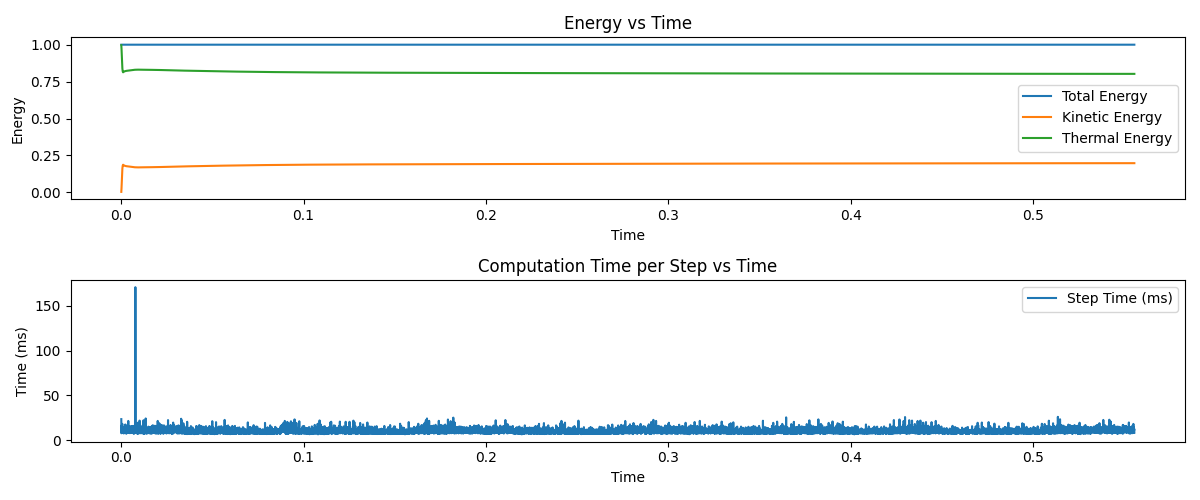

In [ ]:
fig, axis = plt.subplots(2,1, figsize = (12, 5), squeeze = False)

axis[0,0].plot(times, [x[2] for x in trajectory], label = 'Total Energy')
axis[0,0].plot(times, [x[3] for x in trajectory], label = 'Kinetic Energy')
axis[0,0].plot(times, [x[4] for x in trajectory], label = 'Thermal Energy')
axis[0,0].legend()
axis[0,0].set_xlabel('Time')
axis[0,0].set_ylabel('Energy')
axis[0,0].set_title('Energy vs Time')

axis[1,0].plot(times, [x[5] for x in trajectory], label = 'Step Time (ms)')
axis[1,0].legend()
axis[1,0].set_xlabel('Time')
axis[1,0].set_ylabel('Time (ms)')
axis[1,0].set_title('Computation Time per Step vs Time')

fig.tight_layout()

In [ ]:
print(f'Mean computation time per step: {sum(x[5] for x in trajectory)/len(trajectory):.3f} ms')
print(f'Max computation time for a step: {max(x[5] for x in trajectory):.3f} ms')
print(f'Stddev of computation time for steps: {torch.tensor([x[5] for x in trajectory]).std():.3f} ms')

Mean computation time per step: 9.955 ms
Max computation time for a step: 170.719 ms
Stddev of computation time for steps: 3.127 ms


Adjusted time for plotting: 0.5555510520935059
tensor(5.8897e-05, device='cuda:0')


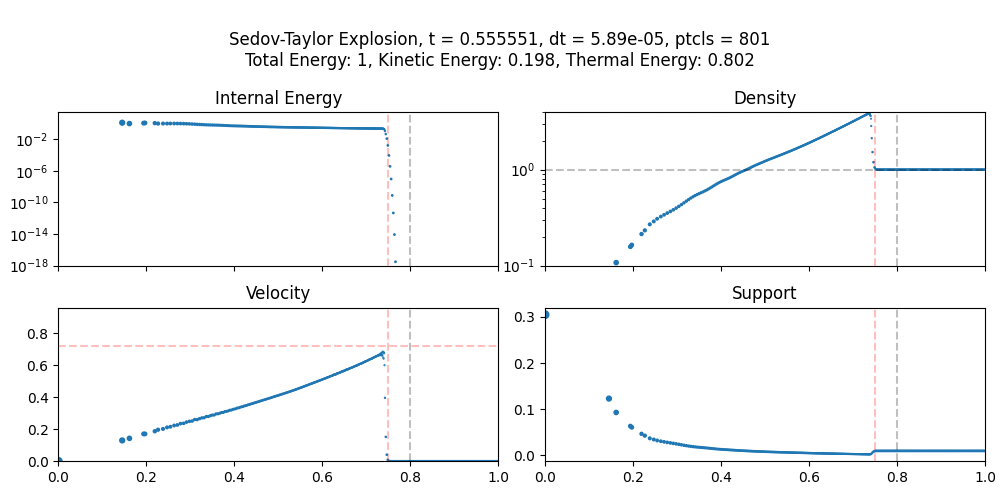

In [ ]:
fig, axis = plt.subplots(2, 2, figsize=(10, 5), squeeze=False, sharex=True, sharey=False)

axis[0,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.internalEnergies.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[1,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.velocities.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[1,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.supports.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)

axis[0,0].set_title('Internal Energy')
axis[0,1].set_title('Density')
axis[1,0].set_title('Velocity')
axis[1,1].set_title('Support')

kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy

fig.suptitle(f'\nSedov-Taylor Explosion, t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
fig.tight_layout()

# prefix = './images/sedov_1d_201_sharp/'
# os.makedirs(prefix, exist_ok = True)

rt = rad_t(runningState.t)
# vt = vel_t(runningState.t)
    
    
def setupPlot(axis, t):
    vs, r2, v2, rho2, P2 = answer.shockState(t)
    rt = rad_t(t)
    
    for ax in axis.flatten():
        ax.axvline(r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(-r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(rt, color = 'red', linestyle = '--', alpha = 0.25)
        ax.axvline(-rt, color = 'red', linestyle = '--', alpha = 0.25)
        
        
    # axis[1,0].axhline(vt, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho0, color = 'black', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho2, color = 'black', linestyle = '--', alpha = 0.25)

    axis[0,0].set_xlim(0, 1)
    axis[0,1].set_xlim(0, 1)
    axis[1,0].set_xlim(0, 1)
    axis[1,1].set_xlim(0, 1)

    axis[0,0].set_ylim(1e-18, 30)
    axis[0,1].set_ylim(0.1, 4)
    axis[1,0].set_ylim(0, vs)

    axis[0,0].set_yscale('log')
    axis[0,1].set_yscale('log')

t = runningState.t.cpu() if isinstance(runningState.t, torch.Tensor) else runningState.t
# t = t * initial_dt.cpu().item() / config.dt
print(f"Adjusted time for plotting: {t}")
print(initial_dt)
setupPlot(axis, t)

# fig.savefig(f'{prefix}/frame_{0:06d}.png')

In [ ]:
currentState = runningState.state
verletScale = 1

adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = verletScale, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

numNeighbors = adjacency.numNeighbors

currentState.densities = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = config.supportMode,
    ),
    domain = config.domain,
    adjacency = adjacency,
)

currentState.entropies, _, currentState.pressures, currentState.soundspeeds = idealGasEOS(
    A = None,
    u = currentState.internalEnergies,
    P = None,
    rho = currentState.densities,
    gamma = compressibleSPHConfig.gamma,
)

from compressibleSPH.modules.adaptiveSupport import computeOmega
omega = computeOmega(currentState, 
        OperationProperties(
            kernel = config.kernel,
            supportMode = SupportScheme.Gather,
        ),
        domain = config.domain,
        adjacency = adjacency
)

gradHState = GradHState(
    queryOmegas = omega
)

# gradHState.queryOmegas = torch.ones_like(gradHState.queryOmegas)

In [ ]:
from diffSPH.schemes.states.compressiblesph import CompressibleState as CompState
from diffSPH.kernels import getSPHKernelv2
from diffSPH.neighborhood import evaluateNeighborhood

from diffSPH.modules.compSPH import compSPH_acceleration, compSPH_dudt, compute_fij

diffSPHDiffusionConfig = {    
    'diffusion':{
        'C_l': 1,
        'C_q': 2,
        'Cu_l': 1,
        'Cu_q': 2,
        'monaghanSwitch': True,
        'viscosityTerm': 'Monaghan',
        'correctXi': True,
        
        'viscosityFormulation': 'Monaghan1992',
        'thermalConductivityFormulation': 'Price2012_98',
        'signalTerm': 'Price2019',
        'K': 1.0,
        
        'thermalConductivity' : 0.5,
    },
    'diffusionSwitch':{
        'scheme': ViscositySwitch.NoneSwitch,
        'limitXi': False,
    },
    'domain': config.domain,
    'kernel': KernelType.Wendland2,
    'verbose': True,
}

diffSPHState = CompState(
    positions = currentState.positions,
    velocities = currentState.velocities,
    densities = currentState.densities,
    supports = currentState.supports,
    internalEnergies = currentState.internalEnergies,
    totalEnergies = currentState.totalEnergies,
    entropies = currentState.entropies,
    soundspeeds= currentState.soundspeeds,
    masses = currentState.masses,
    kinds = currentState.kinds,
    materials = currentState.materials,
    UIDs = currentState.UIDs,
    pressures = currentState.pressures,
    omega = gradHState.queryOmegas,
)

wrappedKernel = getSPHKernelv2(KernelType.Wendland2)
verletScale = 1
neighborhood, neighbors = evaluateNeighborhood(diffSPHState, config.domain, KernelType.Wendland2, verletScale = verletScale, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)


dvdt_dsph, ap_ij_dsph, av_ij_dsph = compSPH_acceleration(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, diffSPHDiffusionConfig)

print(f'Max pressure acceleration: {ap_ij_dsph.abs().max()}')
print(f'Max viscosity acceleration: {av_ij_dsph.abs().max()}')
print(f'Max total acceleration: {(dvdt_dsph).abs().max()}')

dudt_dsph = compSPH_dudt(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, diffSPHDiffusionConfig)

print(f'Max du/dt: {dudt_dsph.abs().max()}')

Max pressure acceleration: 644.6320190429688
Max viscosity acceleration: 513.4705200195312
Max total acceleration: 1097.9718017578125
Max du/dt: 1713.9971923828125


In [ ]:
compressibleSPHConfig.diffusionParams.viscosityTerm = 3
compressibleSPHConfig.diffusionParams.C_l = 1
compressibleSPHConfig.diffusionParams.C_q = 2
compressibleSPHConfig.diffusionParams.correctXi = True

In [ ]:
from sphWarpCore.kernels.wp_kernel import eval_packing
sphKernel_xi(config.kernel.value, config.dim), eval_kernelScale(config.dim, config.kernel.value), eval_packing(config.kernel.value)

(2.409215095, 2.20794, 1.487)

In [ ]:
print(config.kernel, config.kernel.value)

KernelFunctions.Wendland2 0


In [ ]:
from diffSPH.kernels import Kernel_xi, Kernel_Scale, eval_packingRatio
Kernel_xi(KernelType.Wendland2, config.dim), Kernel_Scale(KernelType.Wendland2, config.dim), eval_packingRatio(KernelType.Wendland2)

(2.409215095, 1.620185, 1.487)

In [ ]:
from compressibleSPH.modules.compSPH.accel import computeCompSPHAccelWarp

dvdt, pressureAccel_ij, viscosityAccel_ij = computeCompSPHAccelWarp(
    queryParticles = currentState,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = config.supportMode
    ),
    domain = config.domain,
    conductivityParams= compressibleSPHConfig.diffusionParams,

    queryEnergies = currentState.internalEnergies,
    queryVelocities= currentState.velocities,
    queryCs = currentState.soundspeeds,
    queryAlphas = currentState.alphas,
    queryPressures = currentState.pressures,

    adjacency = adjacency,
    gradHState = gradHState
)
print(f'Max pressure acceleration: {pressureAccel_ij.abs().max()}')
print(f'Max viscosity acceleration: {viscosityAccel_ij.abs().max()}')
print(f'Max total acceleration: {(dvdt).abs().max()}')

Max pressure acceleration: 644.6320190429688
Max viscosity acceleration: 513.470458984375
Max total acceleration: 1097.9716796875


In [ ]:
print(f'Max difference in pressure acceleration: {(pressureAccel_ij - ap_ij_dsph).abs().max()}')
print(f'Max difference in viscosity acceleration: {(viscosityAccel_ij - av_ij_dsph).abs().max()}')
print(f'Max difference in total acceleration: {(dvdt - dvdt_dsph).abs().max()}')

Max difference in pressure acceleration: 0.0001220703125
Max difference in viscosity acceleration: 0.000152587890625
Max difference in total acceleration: 0.000244140625


In [ ]:
viscosityAccel_ij[viscosityAccel_ij.abs() > 1e-3]

tensor([-2.8952e-03, -1.3735e-02, -7.3059e-02, -1.0228e-03, -3.7896e-02,
        -4.2901e-01, -6.0238e-01, -1.1206e-01,  2.8952e-03,  1.3735e-02,
         3.7895e-02, -1.3105e+00, -5.7441e+00, -4.6099e+00, -2.2718e+00,
        -2.6743e-01,  7.3054e-02,  4.2902e-01,  1.3104e+00, -1.9595e+01,
        -3.6851e+01, -1.9811e+01, -1.1277e+01, -5.1101e+00, -1.2410e+00,
         1.0238e-03,  6.0238e-01,  5.7443e+00,  1.9595e+01, -1.7045e+02,
        -1.2107e+02, -4.9943e+01, -2.8602e+01, -1.2304e+01, -2.1676e+00,
         1.1208e-01,  4.6097e+00,  3.6851e+01,  1.7046e+02, -5.1346e+02,
        -3.0872e+02, -8.1415e+01, -3.2260e+01, -6.4700e+00, -1.9034e-03,
         2.2716e+00,  1.9811e+01,  1.2108e+02,  5.1346e+02, -3.5707e+02,
        -2.1219e+02, -5.2532e+01, -3.0644e+00,  2.6751e-01,  1.1276e+01,
         4.9943e+01,  3.0870e+02,  3.5704e+02, -7.6278e+01,  5.1097e+00,
         2.8602e+01,  8.1407e+01,  2.1217e+02,  7.6278e+01,  1.2410e+00,
         1.2305e+01,  3.2260e+01,  5.2532e+01, -7.5

In [ ]:
# Max du/dt: 3417.611328125, Max du/dt diffSPH: 1713.9971923828125
# Max Diff: 1703.6141357421875
# Max du/dt: 3395.027099609375, Max du/dt diffSPH: 1703.37109375
# Max Diff: 1691.656005859375
# Max du/dt: 3395.327880859375, Max du/dt diffSPH: 1703.5166015625
# Max Diff: 1691.811279296875
# Max du/dt: 3373.2021484375, Max du/dt diffSPH: 1693.142578125
# Max Diff: 1680.0595703125

In [ ]:
config.supportMode

<SupportScheme.Gather: 11>

In [ ]:
from compressibleSPH.modules.compSPH.dudt import computeCompSPHdudtWarp
from sphWarpCore.enumTypes import SupportScheme
dudt = computeCompSPHdudtWarp(
    queryParticles = currentState,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = SupportScheme.Gather
    ),
    domain = config.domain,
    conductivityParams= compressibleSPHConfig.diffusionParams,

    queryEnergies = currentState.internalEnergies,
    queryVelocities= currentState.velocities,
    queryCs = currentState.soundspeeds,
    queryAlphas = currentState.alphas,
    queryPressures = currentState.pressures,

    adjacency = adjacency,
    gradHState = gradHState
)
print(f'Max du/dt: {dudt.abs().max()}')

Max du/dt: 3417.611328125


In [ ]:
from diffSPH.enums import SupportScheme as DiffSPHSupportScheme
dudt_dsph = compSPH_dudt(diffSPHState, wrappedKernel, neighbors.get('noghost'), DiffSPHSupportScheme.Gather, diffSPHDiffusionConfig)

print(f'Max du/dt: {dudt_dsph.abs().max()}')

Max du/dt: 1713.99755859375


In [ ]:
dudt[dudt.abs() > 1e-3], dudt_dsph[dudt_dsph.abs() > 1e-3], (dudt / dudt_dsph)[(dudt.abs() > 1e-3) | (dudt_dsph.abs() > 1e-3)]

(tensor([ 2.3929e-03,  1.4522e-01,  5.2197e+00,  5.7400e+01,  2.8110e+02,
          8.0004e+02,  8.3915e+02,  5.9904e+02,  2.5041e+02, -4.0072e+00,
         -9.4935e+01,  8.4828e+01,  7.2798e+01, -8.1961e+01, -2.5443e+02,
         -3.1816e+02, -2.3370e+02, -1.5674e+02, -1.1915e+02, -1.3109e+02,
         -1.5386e+02, -1.7737e+02, -1.4204e+02, -8.4432e+01, -8.0714e+01,
         -4.4229e+03, -8.0712e+01, -8.4431e+01, -1.4204e+02, -1.7737e+02,
         -1.5386e+02, -1.3108e+02, -1.1915e+02, -1.5673e+02, -2.3370e+02,
         -3.1816e+02, -2.5445e+02, -8.1961e+01,  7.2802e+01,  8.4828e+01,
         -9.4939e+01, -4.0099e+00,  2.5044e+02,  5.9907e+02,  8.3914e+02,
          8.0002e+02,  2.8110e+02,  5.7399e+01,  5.2195e+00,  1.4524e-01,
          2.3929e-03], device='cuda:0'),
 tensor([ 2.3929e-03,  1.4522e-01,  5.2197e+00,  5.7400e+01,  2.8110e+02,
          8.0004e+02,  8.3915e+02,  5.9904e+02,  2.5041e+02, -4.0072e+00,
         -9.4935e+01,  8.4828e+01,  7.2798e+01, -8.1961e+01, -2.5443e+0

In [ ]:
from diffSPH.enums import EnergyScheme as EnergySchemeDiffSPH
v_halfstep = diffSPHState.velocities + 0.5 * config.dt * dvdt


energyScheme = EnergyScheme.CRK
print(f'Energy scheme: {energyScheme} [value: {energyScheme.value}]' )


# f_ij
print(f_ij)
print(f'Max f_ij: {f_ij.abs().max()}, Mean: {f_ij.mean()}, Min: {f_ij.min()}, Max: {f_ij.max()}')
print(f'Max deviation from 0.5: {(f_ij - 0.5).abs().max()}')

diffSPHDiffusionConfig['energyScheme'] = EnergySchemeDiffSPH.CRK
f_ij_dsph = compute_fij(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, diffSPHDiffusionConfig, config.dt, v_halfstep, ap_ij_dsph, av_ij_dsph)
# print(f_ij_dsph)
print(f'Max f_ij (diffSPH): {f_ij_dsph.abs().max()}, Mean: {f_ij_dsph.mean()}, Min: {f_ij_dsph.min()}, Max: {f_ij_dsph.max()}')
print(f'Max deviation from 0.5 (diffSPH): {(f_ij_dsph - 0.5).abs().max()}')

print(f'Max difference in f_ij: {(f_ij - f_ij_dsph).abs().max()}')

Energy scheme: EnergyScheme.CRK [value: 5]
tensor([0.4942, 0.4961, 0.5020,  ..., 0.4980, 0.4961, 0.4941], device='cuda:0')
Max f_ij: 0.9941655993461609, Mean: 0.5, Min: 0.0058343675918877125, Max: 0.9941655993461609
Max deviation from 0.5: 0.4941656291484833
Max f_ij (diffSPH): 0.9941656589508057, Mean: 0.5, Min: 0.005834357813000679, Max: 0.9941656589508057
Max deviation from 0.5 (diffSPH): 0.49416565895080566
Max difference in f_ij: 1.0132789611816406e-06


In [ ]:
print('Max pressure deviation:', (ap_ij_dsph - pressureAccel_ij).abs().max())
print('Max viscosity deviation:', (av_ij_dsph - viscosityAccel_ij).abs().max())
print('Max total acceleration deviation:', (dvdt_dsph - dvdt).abs().max())
print('Max du/dt deviation:', (dudt_dsph - dudt).abs().max())

Max pressure deviation: tensor(0.0005, device='cuda:0')
Max viscosity deviation: tensor(9.5367e-07, device='cuda:0')
Max total acceleration deviation: tensor(0.0011, device='cuda:0')
Max du/dt deviation: tensor(0.0078, device='cuda:0')


In [ ]:
pressureAccel_ij
# viscosityAccel_ij

tensor([[  354.6518],
        [  945.7905],
        [ 1061.2377],
        ...,
        [-1061.2208],
        [ -938.4009],
        [ -349.1239]], device='cuda:0')

In [ ]:
config.dt = 1e-4
t_limit = goalTime
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
nSteps = 512

runningState = compSystem.initializeNewState()
for i in (tq := tqdm(range(nSteps), leave = True)):
    result = integrator.function(
        state = runningState,
        f = compressibleSPH_Monaghan,
        dt = config.dt,  
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
    )

    runningState = result.state

Running with dt: 0.0001, which gives nSteps: 5556


  0%|          | 0/512 [00:00<?, ?it/s]

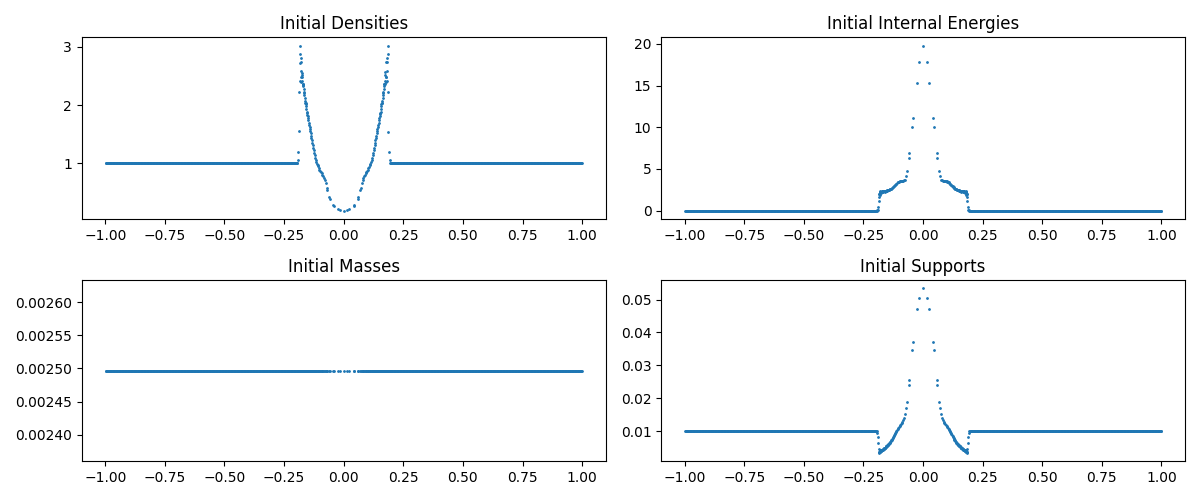

In [ ]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], runningState.state.positions, runningState.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], runningState.state.positions, runningState.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], runningState.state.positions, runningState.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], runningState.state.positions, runningState.state.supports, title = 'Initial Supports')
fig.tight_layout()

Adjusted time for plotting: 0.05120000000000044
tensor(0.0914, device='cuda:0')


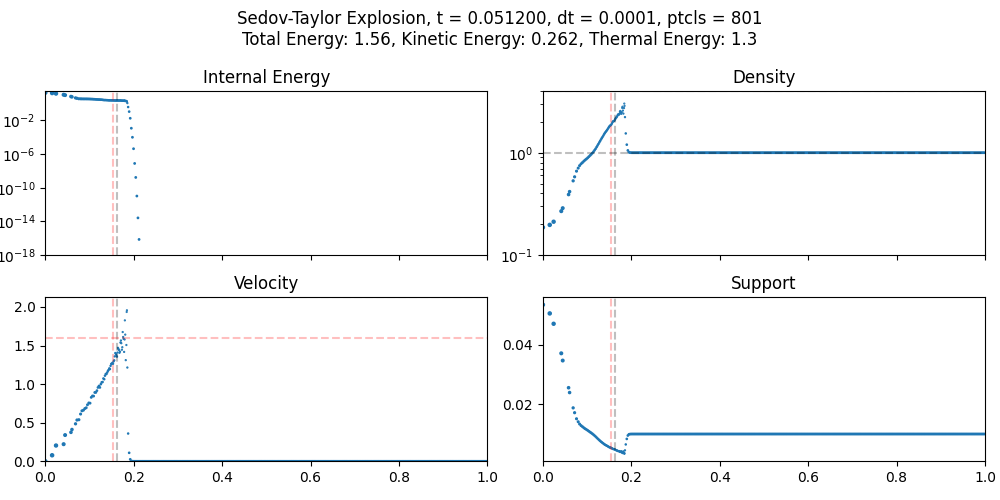

In [ ]:
fig, axis = plt.subplots(2, 2, figsize=(10, 5), squeeze=False, sharex=True, sharey=False)

axis[0,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.internalEnergies.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[1,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.velocities.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[1,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.supports.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)

axis[0,0].set_title('Internal Energy')
axis[0,1].set_title('Density')
axis[1,0].set_title('Velocity')
axis[1,1].set_title('Support')

kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy

fig.suptitle(f'Sedov-Taylor Explosion, t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
fig.tight_layout()

# prefix = './images/sedov_1d_201_sharp/'
# os.makedirs(prefix, exist_ok = True)

rt = rad_t(runningState.t)
# vt = vel_t(runningState.t)
    
    
def setupPlot(axis, t):
    vs, r2, v2, rho2, P2 = answer.shockState(t)
    rt = rad_t(t)
    
    for ax in axis.flatten():
        ax.axvline(r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(-r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(rt, color = 'red', linestyle = '--', alpha = 0.25)
        ax.axvline(-rt, color = 'red', linestyle = '--', alpha = 0.25)
        
        
    # axis[1,0].axhline(vt, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho0, color = 'black', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho2, color = 'black', linestyle = '--', alpha = 0.25)

    axis[0,0].set_xlim(0, 1)
    axis[0,1].set_xlim(0, 1)
    axis[1,0].set_xlim(0, 1)
    axis[1,1].set_xlim(0, 1)

    axis[0,0].set_ylim(1e-18, 30)
    axis[0,1].set_ylim(0.1, 4)
    axis[1,0].set_ylim(0, vs)

    axis[0,0].set_yscale('log')
    axis[0,1].set_yscale('log')

t = runningState.t.cpu() if isinstance(runningState.t, torch.Tensor) else runningState.t
# t = t * initial_dt.cpu().item() / config.dt
print(f"Adjusted time for plotting: {t}")
print(initial_dt)
setupPlot(axis, t)

# fig.savefig(f'{prefix}/frame_{0:06d}.png')